# Multiple Linear Regression

Extending simple linear regression to more than one input feature. The model still fits a straight line — just in higher-dimensional space, so with two features it's a plane, and with more it's a hyperplane.

**What changes vs. Simple Linear Regression?**
- `y = m1*x1 + m2*x2 + ... + mk*xk + b` — one slope (coefficient) per feature
- Same `.fit()` / `.predict()` API — sklearn doesn't care how many features you pass in
- When comparing models with different feature counts, use **adjusted R²** instead of plain R² (see [04_regression_metrics.ipynb](04_regression_metrics.ipynb))

**Note:** For comprehensive evaluation metrics (MAE, RMSE, R², adjusted R², residual plots), see [04_regression_metrics.ipynb](04_regression_metrics.ipynb)

## 0. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

## 1. Multiple Features with Real Data

Start with `placement.csv` (CGPA → package) and add a second feature to demonstrate fitting with 2+ features.

In [3]:
df = pd.read_csv('placement.csv')
df.head()

,cgpa,package
0,6.48,2.37
1,6.84,2.79
2,4.76,1.72
3,8.54,4.32
4,5.11,2.22


In [4]:
# Add a second feature (IQ-style score) that's actually correlated with package
np.random.seed(3)
df['iq'] = np.round(100 + (df['package'] - df['package'].mean()) * 15
                    + np.random.normal(0, 8, df.shape[0]))
df.head()

,cgpa,package,iq
0,6.48,2.37,105.0
1,6.84,2.79,101.0
2,4.76,1.72,82.0
3,8.54,4.32,105.0
4,5.11,2.22,87.0


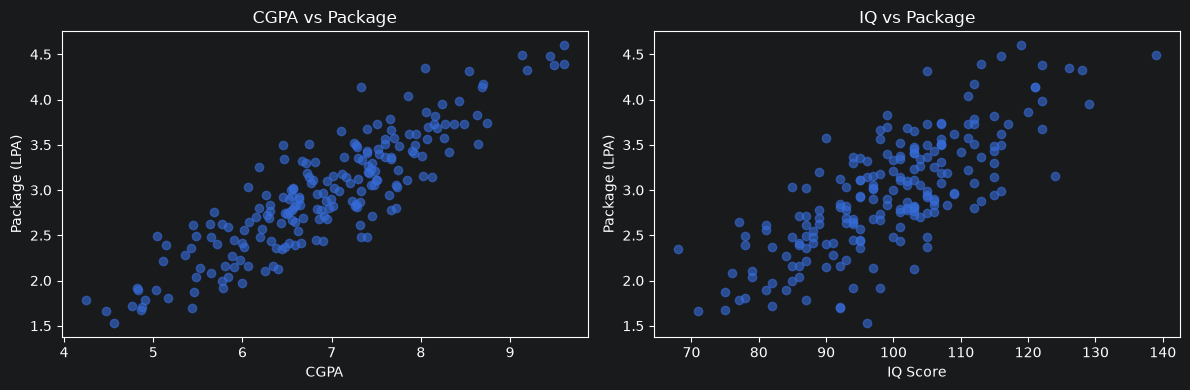

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['cgpa'], df['package'], alpha=0.6)
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Package (LPA)')
axes[0].set_title('CGPA vs Package')

axes[1].scatter(df['iq'], df['package'], alpha=0.6)
axes[1].set_xlabel('IQ Score')
axes[1].set_ylabel('Package (LPA)')
axes[1].set_title('IQ vs Package')

plt.tight_layout()
plt.show()

## 2. Fit with Multiple Features

The only difference from simple regression: pass multiple columns to `X`.

In [6]:
X = df[['cgpa', 'iq']]
y = df['package']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (160, 2)
Test set: (40, 2)


In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.4 ,0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.464
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [8]:
print(f"Coefficients (one per feature):")
for feature, coef in zip(X.columns, lr.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Intercept: {lr.intercept_:.4f}")

Coefficients (one per feature):
  cgpa: 0.3956
  iq: 0.0171
Intercept: -1.4644


## 3. Interpreting Multiple Coefficients

Each coefficient tells you the effect of one feature, holding others constant.

In [9]:
print(f"Model equation: package = {lr.coef_[0]:.4f}*cgpa + {lr.coef_[1]:.6f}*iq + {lr.intercept_:.4f}")
print()
print(f"Interpretation:")
print(f"  - For each +1 in CGPA (holding IQ constant), package increases by {lr.coef_[0]:.4f} LPA")
print(f"  - For each +1 in IQ score (holding CGPA constant), package increases by {lr.coef_[1]:.6f} LPA")

Model equation: package = 0.3956*cgpa + 0.017053*iq + -1.4644

Interpretation:
  - For each +1 in CGPA (holding IQ constant), package increases by 0.3956 LPA
  - For each +1 in IQ score (holding CGPA constant), package increases by 0.017053 LPA


## 4. Make Predictions

Predict on new data with multiple features.

In [10]:
y_pred = lr.predict(X_test)
print(f"First 5 predictions:\n{y_pred[:5]}")
print(f"\nActual values:\n{y_test.values[:5]}")

First 5 predictions:
[2.30730726 2.92798516 2.70699945 2.78857237 2.79174369]

Actual values:
[1.97 3.14 2.92 3.02 3.25]


## 5. Geometric Intuition: 2 Features → Plane

With exactly 2 features, the regression fit is a **plane** (not a line). Synthetic data and a 3D plot make this visible.

In [11]:
# Generate synthetic data: 2 features, known relationship
X_synth, y_synth = make_regression(n_samples=100, n_features=2, n_informative=2, 
                                    n_targets=1, noise=50, random_state=13)

synth_df = pd.DataFrame({'feature1': X_synth[:,0], 'feature2': X_synth[:,1], 'target': y_synth})
synth_df.head()

,feature1,feature2,target
0,1.892742,0.490872,216.617730
1,0.514329,0.217452,76.023958
2,-0.389656,0.291641,-63.806961
3,0.817306,0.154205,172.989994
4,0.501137,1.749242,56.024963


In [12]:
# 3D scatter plot
fig = px.scatter_3d(synth_df, x='feature1', y='feature2', z='target',
                     title='2 Features → Fitted Plane')
fig.show()

In [13]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_synth, y_synth, 
                                                              test_size=0.2, random_state=2)

lr_s = LinearRegression()
lr_s.fit(X_train_s, y_train_s)

print(f"Coefficients: {lr_s.coef_}")
print(f"Intercept: {lr_s.intercept_:.2f}")

Coefficients: [78.52632743 30.44600105]
Intercept: -0.23


In [14]:
# Create mesh for the fitted plane
x_range = np.linspace(synth_df['feature1'].min(), synth_df['feature1'].max(), 10)
y_range = np.linspace(synth_df['feature2'].min(), synth_df['feature2'].max(), 10)
x_mesh, y_mesh = np.meshgrid(x_range, y_range)
z_mesh = lr_s.intercept_ + lr_s.coef_[0]*x_mesh + lr_s.coef_[1]*y_mesh

# Plot with plane overlay
fig = px.scatter_3d(synth_df, x='feature1', y='feature2', z='target',
                     title='2 Features: Fitted Plane Overlaid')
fig.add_scatter3d(x=x_mesh.flatten(), y=y_mesh.flatten(), z=z_mesh.flatten(),
                   mode='markers', marker=dict(size=2, color='red'), name='Fitted Plane')
fig.show()

## 6. With 3+ Features: Hyperplane (Not Visualizable)

The concept scales: 3 features → hyperplane in 4D space (can't visualize directly). The math is identical, but we can't plot it.

In [15]:
X_3feat, y_3feat = make_regression(n_samples=100, n_features=3, n_informative=3,
                                   n_targets=1, noise=100, random_state=42)

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3feat, y_3feat,
                                                              test_size=0.2, random_state=2)

lr_3 = LinearRegression()
lr_3.fit(X_train_3, y_train_3)

print(f"3 Features → 3 Coefficients:")
for i, coef in enumerate(lr_3.coef_):
    print(f"  Feature {i+1}: {coef:.4f}")
print(f"Intercept: {lr_3.intercept_:.2f}")
print(f"\n(This hyperplane exists in 4D space and can't be visualized directly)")

3 Features → 3 Coefficients:
  Feature 1: 34.8479
  Feature 2: 67.8109
  Feature 3: 36.1343
Intercept: 18.63

(This hyperplane exists in 4D space and can't be visualized directly)


## 7. Evaluation

For comprehensive metrics (MAE, RMSE, R², adjusted R²) and residual analysis, see [04_regression_metrics.ipynb](04_regression_metrics.ipynb).

**Key point about adjusted R²:** When comparing models with different feature counts, use **adjusted R²**, not plain R². Plain R² always increases (or stays same) when adding any feature — even useless ones — because the model has more freedom to fit. Adjusted R² penalizes for each added feature.

---
## Multiple Linear Regression Cheat Sheet

### Selecting Multiple Features
| Code | Description |
|---|---|
| `df[['feat1','feat2']]` | Select multiple columns as 2D input |
| `df.iloc[:, 0:3]` | Select first 3 columns |
| `df.drop('target', axis=1)` | All columns except target |

### Model Fitting (Same API as Simple Regression)
| Code | Description |
|---|---|
| `lr.fit(X_train, y_train)` | Fits to any number of features |
| `lr.predict(X_test)` | Predicts on test data |
| `lr.coef_` | Array of coefficients, one per feature |

### Geometric Intuition
| # Features | Fitted Shape | Visualizable? |
|---|---|---|
| 1 | Line (2D) | ✓ Yes |
| 2 | Plane (3D) | ✓ Yes (3D plot) |
| 3 | Hyperplane (4D) | ✗ No |
| 4+ | Hyperplane (5D+) | ✗ No |

### Comparison: Simple vs Multiple
| Aspect | Simple (1 feature) | Multiple (2+ features) |
|---|---|---|
| Equation | `y = m*x + b` | `y = m1*x1 + m2*x2 + ... + b` |
| `lr.coef_` | Single value | Array of values |
| Use adjusted R² | No | **Yes** (when comparing models) |

### Gotchas
- More features → more overfitting risk. Use validation/cross-validation
- Correlated features can cause numerical instability (multicollinearity)
- Always evaluate on test set, never training set